## 1. Khai bao thu vien

In [ ]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    learning_curve, cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss,
    balanced_accuracy_score, ConfusionMatrixDisplay,
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE

RANDOM_STATE = 42
TARGET_COLS = [
    "do_an_1_test", "kiem_thu_phan_mem_test", "thiet_ke_web_co_ban_test",
    "cong_nghe_phan_mem_test", "tieng_anh_1_test", "xac_suat_thong_ke_test",
]
DROP_COLS = [
    "student_id",
    "ky_nang_mem",  # Diem ren luyen - khong phai diem hoc thuat, loai bo
    "giao_duc_the_chat_1", "giao_duc_the_chat_2", "giao_duc_the_chat_3",
]
print("Import thanh cong!")

Import thanh cong!


## 2. Doc & Lam sach du lieu

In [48]:
df_raw = pd.read_csv("clean_hk4-ktpm-with-tests.csv")
df = df_raw[df_raw["student_id"].astype(str).str.strip() != "so_tin_chi"].copy()
df.reset_index(drop=True, inplace=True)
df["student_id"] = df["student_id"].astype(str).str.strip()

FEAT_COLS = [c for c in df.columns if c not in TARGET_COLS and c not in DROP_COLS]
for c in FEAT_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in TARGET_COLS:
    df[c] = df[c].astype(str).str.strip().map({"pass": 1, "fail": 0})

print(f"Dataset: {df.shape}  |  Features: {len(FEAT_COLS)}  |  Targets: {len(TARGET_COLS)}")
df.head()

Dataset: (473, 23)  |  Features: 12  |  Targets: 6


,student_id,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,...,tieng_anh_tang_cuong,giao_duc_the_chat_1,giao_duc_the_chat_2,giao_duc_the_chat_3,cong_nghe_phan_mem_test,do_an_1_test,kiem_thu_phan_mem_test,thiet_ke_web_co_ban_test,tieng_anh_1_test,xac_suat_thong_ke_test
0,12521097,6.7,9.5,9.9,9.5,8.8,9.4,9.1,8.7,9.8,...,6.5,9,7.0,7.0,0,1,1,1,1,1
1,12521054,8.0,9.0,9.3,7.5,7.2,7.9,8.0,8.0,9.2,...,5.5,10,9.0,8.0,1,1,1,1,1,1
2,12521111,2.0,8.1,7.7,7.8,6.3,7.4,7.9,7.5,7.8,...,3.5,8,8.0,7.0,0,1,1,1,1,1
3,10121164,7.3,7.7,3.3,6.5,8.8,5.4,7.5,6.0,7.9,...,3.0,7,7.0,8.0,1,1,1,1,1,1
4,10121688,4.9,8.3,6.3,7.0,7.5,6.2,5.4,6.7,6.9,...,4.0,6,7.0,7.0,1,1,1,1,1,1


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       473 non-null    object 
 1   dai_so_tuyen_tinh                473 non-null    float64
 2   giai_tich                        473 non-null    float64
 3   giai_tich_so                     472 non-null    float64
 4   kien_truc_may_tinh               473 non-null    float64
 5   lap_trinh_python_co_ban          473 non-null    float64
 6   cau_truc_du_lieu_va_giai_thuat   473 non-null    float64
 7   co_so_ky_thuat_lap_trinh         473 non-null    float64
 8   co_so_du_lieu                    473 non-null    float64
 9   lap_trinh_huong_doi_tuong        473 non-null    float64
 10  lap_trinh_ung_dung_windows_form  472 non-null    float64
 11  phap_luat_dai_cuong              473 non-null    float64
 12  ky_nang_mem           

In [50]:
mv = df[FEAT_COLS].isnull().sum()
print("Gia tri NaN:"); display(mv[mv > 0].rename("NaN count"))
zeros = (df[FEAT_COLS] == 0).sum()
print("\nGia tri = 0:"); display(zeros[zeros > 0].rename("Zero count"))
print("\nThong ke mo ta:"); display(df[FEAT_COLS].describe().round(2))

Gia tri NaN:


giai_tich_so                       1
lap_trinh_ung_dung_windows_form    1
tieng_anh_tang_cuong               1
Name: NaN count, dtype: int64


Gia tri = 0:


dai_so_tuyen_tinh                   1
giai_tich                           5
giai_tich_so                        3
kien_truc_may_tinh                  4
cau_truc_du_lieu_va_giai_thuat      2
co_so_ky_thuat_lap_trinh            1
co_so_du_lieu                       8
lap_trinh_huong_doi_tuong           3
lap_trinh_ung_dung_windows_form     8
phap_luat_dai_cuong                 1
tieng_anh_tang_cuong               25
Name: Zero count, dtype: int64


Thong ke mo ta:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,472.00,473.00,473.00,473.00,473.00,473.00,473.00,472.00,473.00,472.00
mean,7.74,7.45,7.01,7.01,7.07,7.13,7.10,6.73,7.20,6.78,7.07,5.81
std,1.26,1.58,1.79,1.69,1.09,1.17,1.36,1.46,1.49,1.91,1.08,2.13
min,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,6.70,6.20,6.30,6.40,6.40,6.30,6.20,6.60,5.90,6.50,5.00
50%,7.80,7.60,7.30,7.30,7.10,7.20,7.20,6.90,7.40,7.20,7.00,6.50
75%,8.60,8.70,8.30,8.20,7.80,7.90,8.00,7.50,8.20,8.02,7.80,7.00
max,10.00,10.00,10.00,9.80,9.50,9.80,9.80,9.40,9.80,9.60,9.30,8.50


## 3. Kham pha & Truc quan hoa du lieu (EDA)

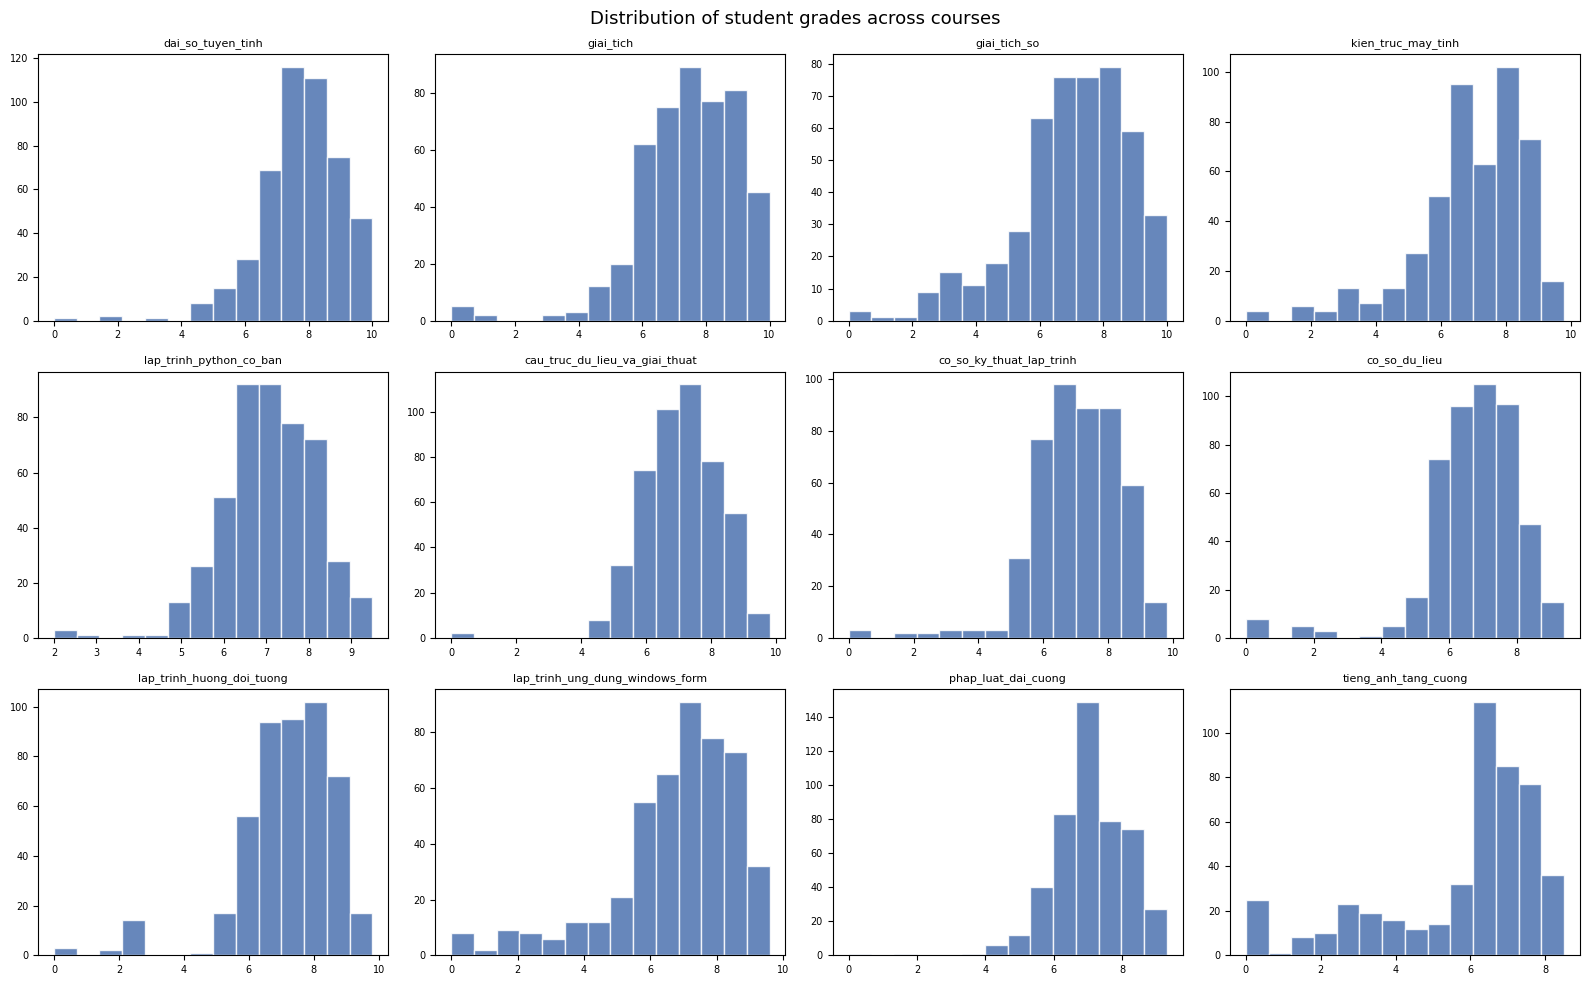

In [51]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flatten(), FEAT_COLS):
    ax.hist(df[c].dropna(), bins=14, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
for ax in axes.flatten()[len(FEAT_COLS):]: ax.set_visible(False)
plt.suptitle("Distribution of student grades across courses", fontsize=13)
plt.tight_layout(); plt.show()

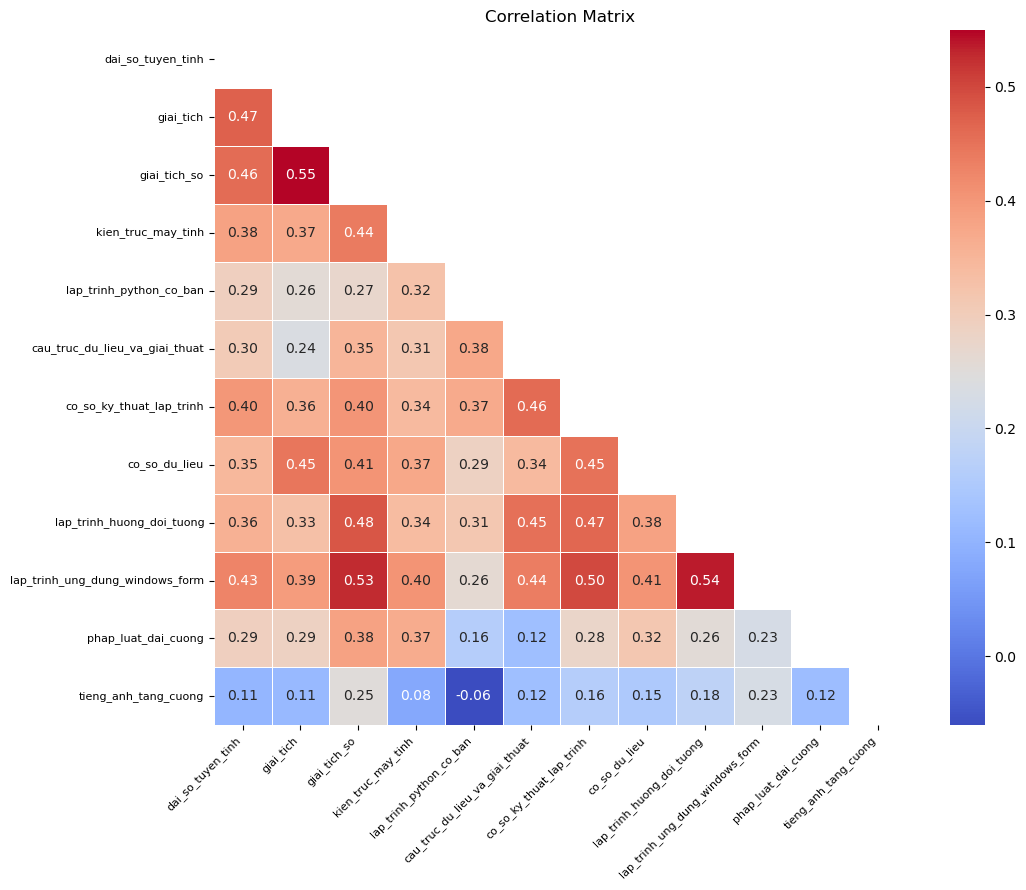

In [52]:
corr = df[FEAT_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4, ax=ax)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

Ti le Pass/Fail tung mon:
  do_an_1_test                          : Pass=392  Fail= 81  Ratio=4.8:1  Fail%=17.1%
  kiem_thu_phan_mem_test                : Pass=448  Fail= 25  Ratio=17.9:1  Fail%=5.3%
  thiet_ke_web_co_ban_test              : Pass=415  Fail= 58  Ratio=7.2:1  Fail%=12.3%
  cong_nghe_phan_mem_test               : Pass=431  Fail= 42  Ratio=10.3:1  Fail%=8.9%
  tieng_anh_1_test                      : Pass=441  Fail= 32  Ratio=13.8:1  Fail%=6.8%
  xac_suat_thong_ke_test                : Pass=434  Fail= 39  Ratio=11.1:1  Fail%=8.2%


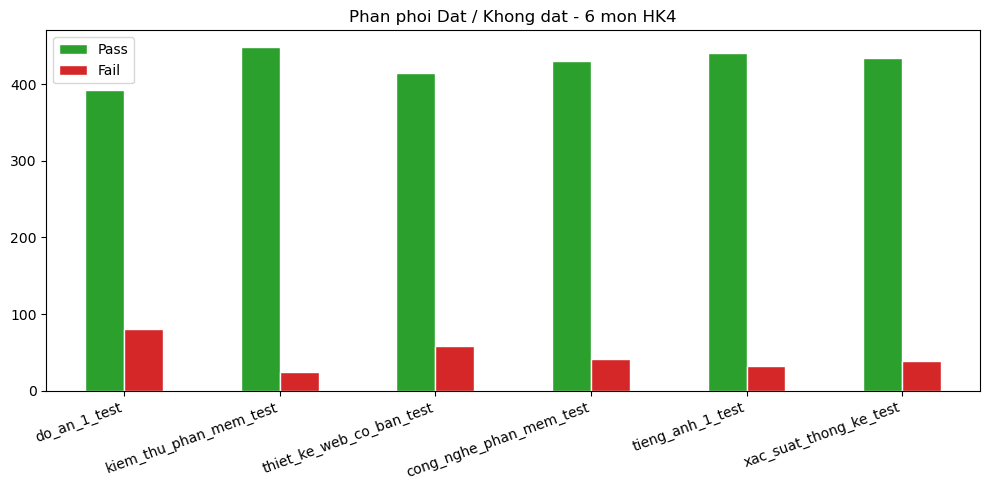

In [53]:
print("Ti le Pass/Fail tung mon:")
for c in TARGET_COLS:
    vc = df[c].value_counts(); p, f = vc.get(1, 0), vc.get(0, 0)
    print(f"  {c:38s}: Pass={p:3d}  Fail={f:3d}  Ratio={p/max(f,1):.1f}:1  Fail%={f/(p+f)*100:.1f}%")
pf = {c: df[c].value_counts().rename({1: "Pass", 0: "Fail"}) for c in TARGET_COLS}
pd.DataFrame(pf).T[["Pass", "Fail"]].plot(
    kind="bar", figsize=(10, 5), color=["#2ca02c", "#d62728"], edgecolor="white")
plt.title("Phan phoi Dat / Khong dat - 6 mon HK4")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 4. Tien xu ly - So sanh truoc/sau

> Doi TARGET o cell ben duoi de phan tich mon khac.

In [54]:
TARGET = "do_an_1_test"
#TARGET = "kiem_thu_phan_mem_test"
#TARGET = "thiet_ke_web_co_ban_test"
#TARGET = "cong_nghe_phan_mem_test"
#TARGET = "tieng_anh_1_test"
#TARGET = "xac_suat_thong_ke_test"
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Mon dang phan tich: {TARGET}")

Mon dang phan tich: do_an_1_test


In [55]:
# ================================================================
# [FIX 1] SUA DATA LEAKAGE trong so sanh preprocessing
#
# LOI CU:
#   X_after = scl.fit_transform(imp.fit_transform(df[FEAT_COLS]))
#   cross_val_score(lr, X_after, ...)
#   => Scaler fit tren TOAN BO data truoc CV => validation fold bi "nhin"
#
# FIX: Boc vao Pipeline => scaler/imputer chi fit tren training fold
# ================================================================
y_all = df[TARGET].dropna().astype(int); idx = y_all.index
X_all = df.loc[idx, FEAT_COLS]

lr_bare = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

X_before = X_all.fillna(0)
f1_b = cross_val_score(lr_bare, X_before, y_all, cv=cv5, scoring="f1_weighted").mean()

pipe_compare = Pipeline([
    ("imp",   SimpleImputer(strategy="median")),
    ("scl",   StandardScaler()),
    ("model", lr_bare),
])
f1_a = cross_val_score(pipe_compare, X_all, y_all, cv=cv5, scoring="f1_weighted").mean()

print(f"LR CV F1 truoc tien xu ly (fillna=0, no scale)      : {f1_b:.4f}")
print(f"LR CV F1 sau tien xu ly   (Median + StandardScaler) : {f1_a:.4f}")
print(f"Cai thien: {(f1_a - f1_b)*100:+.2f}%")

imp_show = SimpleImputer(strategy="median"); scl_show = StandardScaler()
X_after_show = pd.DataFrame(scl_show.fit_transform(imp_show.fit_transform(X_all)), columns=FEAT_COLS)
print("\n[Truoc tien xu ly]:"); display(X_before.describe().round(2))
print("\n[Sau tien xu ly]:"); display(X_after_show.describe().round(2))

LR CV F1 truoc tien xu ly (fillna=0, no scale)      : 0.8401
LR CV F1 sau tien xu ly   (Median + StandardScaler) : 0.8424
Cai thien: +0.23%

[Truoc tien xu ly]:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00
mean,7.74,7.45,7.00,7.01,7.07,7.13,7.10,6.73,7.20,6.76,7.07,5.80
std,1.26,1.58,1.81,1.69,1.09,1.17,1.36,1.46,1.49,1.93,1.08,2.15
min,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,6.70,6.20,6.30,6.40,6.40,6.30,6.20,6.60,5.90,6.50,5.00
50%,7.80,7.60,7.30,7.30,7.10,7.20,7.20,6.90,7.40,7.20,7.00,6.50
75%,8.60,8.70,8.30,8.20,7.80,7.90,8.00,7.50,8.20,8.00,7.80,7.00
max,10.00,10.00,10.00,9.80,9.50,9.80,9.80,9.40,9.80,9.60,9.30,8.50



[Sau tien xu ly]:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-6.17,-4.71,-3.93,-4.16,-4.66,-6.12,-5.24,-4.62,-4.83,-3.56,-6.55,-2.73
25%,-0.59,-0.47,-0.46,-0.42,-0.62,-0.63,-0.59,-0.36,-0.40,-0.46,-0.53,-0.38
50%,0.05,0.10,0.16,0.17,0.03,0.06,0.08,0.12,0.13,0.22,-0.06,0.32
75%,0.69,0.79,0.72,0.71,0.67,0.66,0.67,0.53,0.67,0.64,0.68,0.56
max,1.80,1.61,1.67,1.65,2.23,2.29,2.00,1.83,1.74,1.48,2.07,1.26


## Ham tien ich (dung chung cho cac buoc sau)

In [56]:
def prepare(target):
    ids = df["student_id"]
    X   = df.drop(columns=TARGET_COLS + DROP_COLS, errors="ignore")
    y   = df[target].dropna().astype(int)
    X, y, ids = X.loc[y.index], y, ids.loc[y.index]
    Xtr, Xte, ytr, yte, itr, ite = train_test_split(
        X, y, ids, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    return (X.reset_index(drop=True),   y.reset_index(drop=True),
            Xtr.reset_index(drop=True), Xte.reset_index(drop=True),
            ytr.reset_index(drop=True), yte.reset_index(drop=True),
            itr.reset_index(drop=True), ite.reset_index(drop=True))


def new_smote(k):
    return BorderlineSMOTE(sampling_strategy=1.0, k_neighbors=max(1, k),
                           random_state=RANDOM_STATE)


# ================================================================
# [FIX 2] MultiMetricSelector - Feature selection BEN TRONG Pipeline,
#         dat SAU SMOTE (khac n3 truoc)
#
# LOI N3 TRUOC: dat TRUOC SMOTE (imp -> feat -> smote -> model)
#   => MultiMetricSelector thay du lieu imbalanced (17% Fail / 83% Pass)
#   => F-score, MI, RF Importance bi dominated boi class Pass
#   => Chon sai features => ket qua kem hon
#
# FIX DUNG: imp -> smote -> feat -> scl -> model
#   fit():     imp.fit -> smote.fit_resample -> feat.fit(du_lieu_balanced_50/50) -> model.fit
#   predict(): imp.transform -> [smote bi bo qua] -> feat.transform -> model.predict
#
#   feat.fit()     thay du lieu BALANCED (50/50) tu SMOTE => chon features tot hon
#   feat.transform thay du lieu goc (test set, imbalanced) => van dung selected_indices_ hop le
#   Vi selected_indices_ chi luu INDEX cot, khong phu thuoc phan phoi
#
# LOI CU N2: Feature selection tren toan bo Xtr TRUOC GridSearchCV
#   => Validation fold bi "nhin" => nested data leakage
#   FIX: MultiMetricSelector nam trong Pipeline (duoc fit rieng tung CV fold)
# ================================================================
class MultiMetricSelector(BaseEstimator, TransformerMixin):
    """
    Chon features dua tren trung binh rank tu 3 phuong phap:
    F-score (ANOVA), Mutual Information, Random Forest Importance.
    Sau do loai features co tuong quan > corr_threshold.
    Dat SAU SMOTE trong Pipeline de feature selection thay du lieu balanced.
    Tham so avg_rank_threshold co the duoc GridSearchCV toi uu hoa.
    """
    def __init__(self, feature_names, avg_rank_threshold=8,
                 corr_threshold=0.8, random_state=42):
        self.feature_names      = feature_names
        self.avg_rank_threshold = avg_rank_threshold
        self.corr_threshold     = corr_threshold
        self.random_state       = random_state

    def fit(self, X, y=None):
        # X nhan tu SMOTE: numpy array, du lieu da balanced (50/50)
        X_arr = np.array(X)
        feat  = list(self.feature_names)

        sel_f = SelectKBest(f_classif, k="all").fit(X_arr, y)
        mi    = mutual_info_classif(X_arr, y, random_state=self.random_state)
        rf_fi = RandomForestClassifier(
            n_estimators=100, random_state=self.random_state).fit(X_arr, y)

        rdf = pd.DataFrame({
            "Dac trung": feat,
            "F-score":   sel_f.scores_,
            "Mut.Info":  mi,
            "RF Imp.":   rf_fi.feature_importances_,
        })
        rdf["Avg Rank"] = (
            rdf["F-score"].rank(ascending=False) +
            rdf["Mut.Info"].rank(ascending=False) +
            rdf["RF Imp."].rank(ascending=False)) / 3

        candidates = rdf[rdf["Avg Rank"] <= self.avg_rank_threshold]["Dac trung"].tolist()
        X_cand   = pd.DataFrame(X_arr, columns=feat)[candidates]
        corr_mat = X_cand.corr().abs()
        selected = candidates.copy()
        for i in range(len(candidates)):
            for j in range(i + 1, len(candidates)):
                f1c, f2c = candidates[i], candidates[j]
                if f1c in selected and f2c in selected:
                    if corr_mat.loc[f1c, f2c] > self.corr_threshold:
                        r1 = rdf[rdf["Dac trung"] == f1c]["Avg Rank"].values[0]
                        r2 = rdf[rdf["Dac trung"] == f2c]["Avg Rank"].values[0]
                        selected.remove(f2c if r1 <= r2 else f1c)

        self.selected_features_ = selected
        self.selected_indices_  = [feat.index(f) for f in selected]
        return self

    def transform(self, X):
        # X co the la du lieu goc (imbalanced) khi predict - van dung hop le
        # vi selected_indices_ chi luu INDEX cot, khong phu thuoc phan phoi
        return np.array(X)[:, self.selected_indices_]

    def get_feature_names_out(self):
        return np.array(self.selected_features_)


# ================================================================
# [FIX N5] BO class_weight="balanced" khoi tat ca models
#
# LY DO:
#   SMOTE da can bang du lieu 50/50 truoc khi model hoc
#   => class_weight="balanced" la REDUNDANT (xu ly cung 1 van de)
#   => Dung ca hai gay double-bias toward Fail => over-predict manh
#      (ty le Du doan Fail / Thuc te Fail len toi 3.48x)
#
# KNN khong co class_weight => SMOTE la cach duy nhat xu ly imbalance
# SVM: giu class_weight="balanced" vi kernel RBF can penalty de duy tri RecFail
# LR, RF: bo class_weight (SMOTE du)
#
# Ky vong:
#   - Over-prediction ratio giam tu ~3x xuong ~1.5-2x
#   - Recall Fail giam nhe (~0.05-0.10)
#   - F1 macro tang nhe
# ================================================================
def build_models(k_smote):
    return {
        "Logistic Regression": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("feat",  MultiMetricSelector(feature_names=FEAT_COLS)),  # SAU SMOTE
            ("scl",   StandardScaler()),
            ("model", LogisticRegression(max_iter=1000,
                                         random_state=RANDOM_STATE)),
        ]),
        "KNN": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("feat",  MultiMetricSelector(feature_names=FEAT_COLS)),  # SAU SMOTE
            ("scl",   StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15, weights="uniform")),
        ]),
        "Random Forest": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("feat",  MultiMetricSelector(feature_names=FEAT_COLS)),  # SAU SMOTE
            ("model", RandomForestClassifier(
                n_estimators=200, max_depth=3, min_samples_leaf=10,
                min_samples_split=20, max_features="sqrt",
                random_state=RANDOM_STATE)),
        ]),
        "SVM": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("feat",  MultiMetricSelector(feature_names=FEAT_COLS)),  # SAU SMOTE
            ("scl",   StandardScaler()),
            ("model", SVC(kernel="rbf", class_weight="balanced",
                          probability=True, random_state=RANDOM_STATE)),
        ]),
    }

print("Da dinh nghia: prepare(), new_smote(), MultiMetricSelector, build_models()")
print("Pipeline order: imp -> smote -> feat -> scl -> model")

Da dinh nghia: prepare(), new_smote(), MultiMetricSelector, build_models()
Pipeline order: imp -> smote -> feat -> scl -> model


## 5. Lua chon dac trung 
> **Luu y:** 
> Feature selection THUC SU xay ra ben trong `MultiMetricSelector` trong Pipeline,
> dat SAU SMOTE, duoc fit rieng tren tung training fold trong GridSearchCV.
> Doi TARGET o Section 4 de xem feature importance cua tung mon.

In [57]:
Xf, yf, Xtr, Xte, ytr, yte, *_ = prepare(TARGET)

k_sm = min(2, int(ytr.value_counts().min()) - 1)

imp2 = SimpleImputer(strategy="median"); scl2 = StandardScaler()
Xtr_sc = pd.DataFrame(scl2.fit_transform(imp2.fit_transform(Xtr)), columns=FEAT_COLS)
Xte_sc = pd.DataFrame(scl2.transform(imp2.transform(Xte)), columns=FEAT_COLS)
Xtr_sm, ytr_sm = new_smote(k_sm).fit_resample(Xtr_sc, ytr)
Xtr_sm = pd.DataFrame(Xtr_sm, columns=FEAT_COLS)
print(f"Train sau SMOTE: {Counter(ytr_sm)}")
print("[INFO] Section nay chi de kham pha. Feature selection thuc su nam trong Pipeline.")

Train sau SMOTE: Counter({1: 313, 0: 313})
[INFO] Section nay chi de kham pha. Feature selection thuc su nam trong Pipeline.


In [58]:
print(f"Phan phoi nhan - {TARGET}")
print(f"{'':30s}  {'Train':>18s}  {'Test':>18s}  {'Chenh lech':>12s}")
print("-" * 82)
for label, name in [(0, "Fail"), (1, "Pass")]:
    n_tr = int((ytr == label).sum()); n_te = int((yte == label).sum())
    p_tr = n_tr / len(ytr) * 100;    p_te = n_te / len(yte) * 100
    diff = abs(p_tr - p_te)
    print(f"  {name} ({label}){'':26s}  {n_tr:3d} ({p_tr:5.1f}%)  {n_te:3d} ({p_te:5.1f}%)  {diff:+.2f}%")
print("-" * 82)
diff_fail = abs((ytr==0).sum()/len(ytr) - (yte==0).sum()/len(yte)) * 100
print(f"\n-> Chenh lech ti le Fail: {diff_fail:.2f}%  ", end="")
print("Stratified split chuan" if diff_fail < 1 else "CANH BAO: Phan phoi lech")

Phan phoi nhan - do_an_1_test
                                             Train                Test    Chenh lech
----------------------------------------------------------------------------------
  Fail (0)                             65 ( 17.2%)   16 ( 16.8%)  +0.35%
  Pass (1)                            313 ( 82.8%)   79 ( 83.2%)  +0.35%
----------------------------------------------------------------------------------

-> Chenh lech ti le Fail: 0.35%  Stratified split chuan


### Xep hang 3 phuong phap: F-score, Mutual Information, RF Importance (kham pha)

In [59]:
sel_f = SelectKBest(f_classif, k="all").fit(Xtr_sm, ytr_sm)
mi    = mutual_info_classif(Xtr_sm, ytr_sm, random_state=RANDOM_STATE)
rf_fi = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(Xtr_sm, ytr_sm)

rank_df = pd.DataFrame({
    "Dac trung": FEAT_COLS,
    "F-score":   np.round(sel_f.scores_, 2),
    "Mut.Info":  np.round(mi, 4),
    "RF Imp.":   np.round(rf_fi.feature_importances_, 4),
})
rank_df["Avg Rank"] = (
    rank_df["F-score"].rank(ascending=False) +
    rank_df["Mut.Info"].rank(ascending=False) +
    rank_df["RF Imp."].rank(ascending=False)) / 3
rank_df = rank_df.sort_values("Avg Rank").reset_index(drop=True)
display(rank_df)

,Dac trung,F-score,Mut.Info,RF Imp.,Avg Rank
0,lap_trinh_ung_dung_windows_form,211.12,0.3565,0.2218,1.000000
1,giai_tich,132.79,0.2923,0.1271,3.000000
2,giai_tich_so,118.09,0.3022,0.1192,3.000000
3,lap_trinh_huong_doi_tuong,79.16,0.2647,0.1020,5.333333
4,co_so_du_lieu,68.03,0.2698,0.0595,6.166667
5,lap_trinh_python_co_ban,12.21,0.2981,0.0595,6.833333
6,dai_so_tuyen_tinh,49.23,0.2467,0.0669,7.000000
7,cau_truc_du_lieu_va_giai_thuat,21.83,0.2836,0.0531,7.666667
8,tieng_anh_tang_cuong,3.16,0.3048,0.0506,8.000000
9,co_so_ky_thuat_lap_trinh,29.16,0.2147,0.0509,9.000000


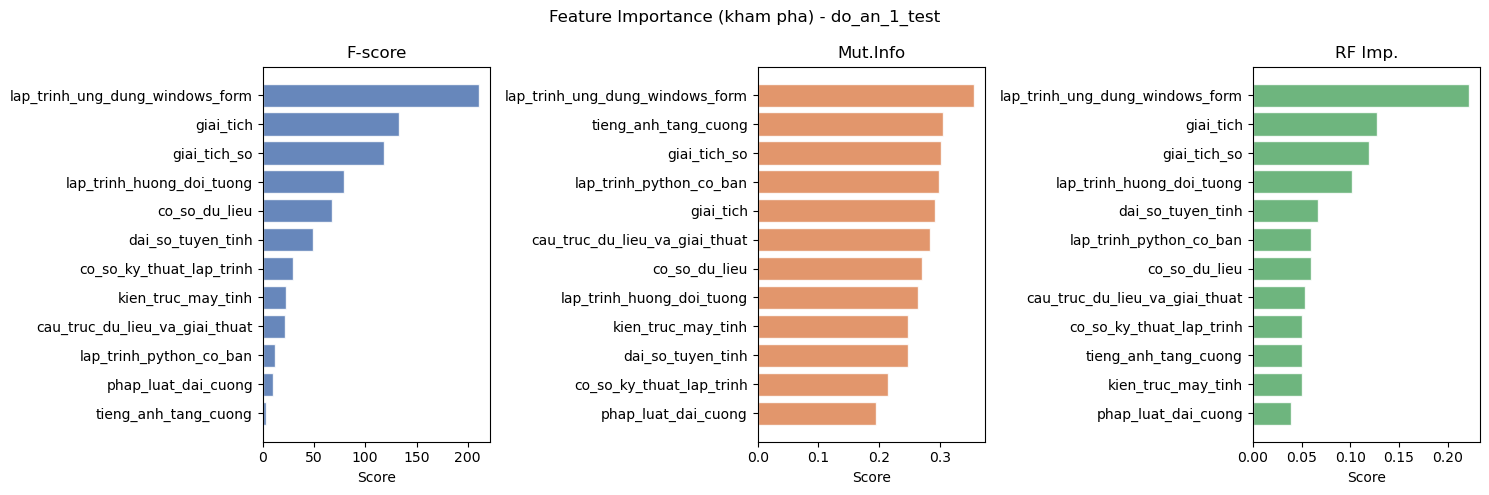

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, color) in zip(axes, [("F-score","#4C72B0"),("Mut.Info","#dd8452"),("RF Imp.","#55a868")]):
    sdf = rank_df.sort_values(col)
    ax.barh(sdf["Dac trung"], sdf[col], color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col); ax.set_xlabel("Score")
plt.suptitle(f"Feature Importance (kham pha) - {TARGET}", fontsize=12)
plt.tight_layout(); plt.show()

In [61]:
AVG_RANK_THRESHOLD = 8
candidates = rank_df[rank_df["Avg Rank"] <= AVG_RANK_THRESHOLD]["Dac trung"].tolist()
print(f"[Kham pha] Features voi Avg Rank <= {AVG_RANK_THRESHOLD} ({len(candidates)} features):")
display(rank_df[rank_df["Avg Rank"] <= AVG_RANK_THRESHOLD][["Dac trung","F-score","Mut.Info","RF Imp.","Avg Rank"]])

corr_mat = Xtr_sm[candidates].corr().abs()
selected_info = candidates.copy()
removed_pairs = []
for i in range(len(candidates)):
    for j in range(i + 1, len(candidates)):
        f1c, f2c = candidates[i], candidates[j]
        if f1c in selected_info and f2c in selected_info:
            if corr_mat.loc[f1c, f2c] > 0.8:
                r1 = rank_df[rank_df["Dac trung"] == f1c]["Avg Rank"].values[0]
                r2 = rank_df[rank_df["Dac trung"] == f2c]["Avg Rank"].values[0]
                drop = f2c if r1 <= r2 else f1c
                selected_info.remove(drop)
                removed_pairs.append((f1c, f2c, corr_mat.loc[f1c, f2c], drop))

if removed_pairs:
    print("\nLoai do tuong quan cao (> 0.8):")
    for f1c, f2c, c, drop in removed_pairs:
        print(f"  {f1c} <-> {f2c}: corr={c:.2f} -> loai '{drop}'")
else:
    print("\nKhong co cap features nao tuong quan > 0.8")

print(f"\n[Kham pha] Uoc tinh features duoc chon ({len(selected_info)}): {selected_info}")
print("\nLUU Y: Features THUC SU nam trong MultiMetricSelector sau SMOTE trong Pipeline.")

[Kham pha] Features voi Avg Rank <= 8 (9 features):


,Dac trung,F-score,Mut.Info,RF Imp.,Avg Rank
0,lap_trinh_ung_dung_windows_form,211.12,0.3565,0.2218,1.000000
1,giai_tich,132.79,0.2923,0.1271,3.000000
2,giai_tich_so,118.09,0.3022,0.1192,3.000000
3,lap_trinh_huong_doi_tuong,79.16,0.2647,0.1020,5.333333
4,co_so_du_lieu,68.03,0.2698,0.0595,6.166667
5,lap_trinh_python_co_ban,12.21,0.2981,0.0595,6.833333
6,dai_so_tuyen_tinh,49.23,0.2467,0.0669,7.000000
7,cau_truc_du_lieu_va_giai_thuat,21.83,0.2836,0.0531,7.666667
8,tieng_anh_tang_cuong,3.16,0.3048,0.0506,8.000000



Khong co cap features nao tuong quan > 0.8

[Kham pha] Uoc tinh features duoc chon (9): ['lap_trinh_ung_dung_windows_form', 'giai_tich', 'giai_tich_so', 'lap_trinh_huong_doi_tuong', 'co_so_du_lieu', 'lap_trinh_python_co_ban', 'dai_so_tuyen_tinh', 'cau_truc_du_lieu_va_giai_thuat', 'tieng_anh_tang_cuong']

LUU Y: Features THUC SU nam trong MultiMetricSelector sau SMOTE trong Pipeline.


## 6. Huan luyen mo hinh - Ket qua Baseline

Pipeline: Imputer -> SMOTE -> MultiMetricSelector -> Scaler -> Model.

In [62]:
baseline_pipes = build_models(k_sm)
baseline_rows  = []

for name, pipe in baseline_pipes.items():
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)
    pp = pipe.predict_proba(Xte)
    n_selected = len(pipe.named_steps["feat"].selected_features_)
    baseline_rows.append({
        "Mo hinh":              name,
        "#Features":            n_selected,
        "Accuracy":             round(accuracy_score(yte, yp), 4),
        "Precision (macro)":    round(precision_score(yte, yp, average="macro",    zero_division=0), 4),
        "Recall (macro)":       round(recall_score(yte, yp,    average="macro",    zero_division=0), 4),
        "F1 (macro)":           round(f1_score(yte, yp,        average="macro",    zero_division=0), 4),
        "Recall Fail":          round(recall_score(yte, yp, labels=[0], average=None, zero_division=0)[0], 4),
        "Precision (weighted)": round(precision_score(yte, yp, average="weighted", zero_division=0), 4),
        "Recall (weighted)":    round(recall_score(yte, yp,    average="weighted", zero_division=0), 4),
        "F1 (weighted)":        round(f1_score(yte, yp,        average="weighted", zero_division=0), 4),
        "Log Loss":             round(log_loss(yte, pp), 4),
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("F1 (macro)", ascending=False)
print(f"Ket qua BASELINE - {TARGET}:")
display(baseline_df)

Ket qua BASELINE - do_an_1_test:


,Mo hinh,#Features,Accuracy,Precision (macro),Recall (macro),F1 (macro),Recall Fail,Precision (weighted),Recall (weighted),F1 (weighted),Log Loss
0,Logistic Regression,8,0.8421,0.7446,0.8552,0.7746,0.8750,0.8945,0.8421,0.8564,0.4247
2,Random Forest,8,0.7895,0.6936,0.7987,0.7132,0.8125,0.8662,0.7895,0.8113,0.4578
3,SVM,8,0.7789,0.6669,0.7425,0.6844,0.6875,0.8390,0.7789,0.7990,0.4354
1,KNN,8,0.6947,0.6399,0.7417,0.6290,0.8125,0.8432,0.6947,0.7326,0.5087


## 7. Tinh chinh tham so - GridSearchCV

In [63]:
# feat__avg_rank_threshold duoc GridSearchCV tune (sau SMOTE, trong Pipeline)
param_grids = {
    "Logistic Regression": {
        "feat__avg_rank_threshold": [8,9],
        "model__C": [0.01, 0.1, 1, 10],
    },
    "KNN": {
        "feat__avg_rank_threshold": [8,9],
        "model__n_neighbors":  [9, 11, 13, 15, 21],
        "model__weights":      ["uniform"],
    },
    "Random Forest": {
        "feat__avg_rank_threshold": [8,9],
        "model__max_depth":        [2, 3, 4],
        "model__min_samples_leaf": [8, 12, 20],
        "model__n_estimators":     [100, 200],
    },
    "SVM": [
        {
            "feat__avg_rank_threshold": [8,9],
            "model__kernel": ["rbf"],
            "model__C":      [0.1, 1, 5, 10, 50, 100],
            "model__gamma":  ["scale", "auto", 0.01, 0.1],
        },
        {
            "feat__avg_rank_threshold": [8,9],
            "model__kernel": ["linear"],
            "model__C":      [0.1, 1, 5, 10, 50],
        },
    ],
}

tuned_pipes = {}; gs_rows = []
for name, pipe in build_models(k_sm).items():
    print(f"[{name}] searching...")
    grid = GridSearchCV(pipe, param_grids[name], cv=cv5,
                        scoring="f1_macro", n_jobs=-1, verbose=0)
    grid.fit(Xtr, ytr)
    best = grid.best_estimator_; tuned_pipes[name] = best

    yp = best.predict(Xte); pp = best.predict_proba(Xte)
    rec_fail = recall_score(yte, yp, labels=[0], average=None, zero_division=0)[0]
    f1m  = f1_score(yte, yp, average="macro",    zero_division=0)
    f1w  = f1_score(yte, yp, average="weighted", zero_division=0)
    n_sel = len(best.named_steps["feat"].selected_features_)
    gs_rows.append({
        "Mo hinh":       name,
        "Best params":   str({k.replace("model__","").replace("feat__","feat:"): v
                              for k, v in grid.best_params_.items()}),
        "#Features":     n_sel,
        "CV F1 macro":   round(grid.best_score_, 4),
        "Test F1 macro": round(f1m, 4),
        "Test F1 w":     round(f1w, 4),
        "Recall Fail":   round(rec_fail, 4),
        "Log Loss":      round(log_loss(yte, pp), 4),
    })
    print(f"  -> Best: {grid.best_params_}  CV={grid.best_score_:.4f}  RecFail={rec_fail:.4f}\n")

gs_df = pd.DataFrame(gs_rows)
print("Ket qua GridSearchCV:"); display(gs_df)

[Logistic Regression] searching...
  -> Best: {'feat__avg_rank_threshold': 9, 'model__C': 1}  CV=0.6558  RecFail=0.8750

[KNN] searching...
  -> Best: {'feat__avg_rank_threshold': 8, 'model__n_neighbors': 11, 'model__weights': 'uniform'}  CV=0.6337  RecFail=0.8125

[Random Forest] searching...
  -> Best: {'feat__avg_rank_threshold': 9, 'model__max_depth': 3, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}  CV=0.6593  RecFail=0.8125

[SVM] searching...
  -> Best: {'feat__avg_rank_threshold': 9, 'model__C': 5, 'model__gamma': 0.01, 'model__kernel': 'rbf'}  CV=0.6594  RecFail=0.7500

Ket qua GridSearchCV:


,Mo hinh,Best params,#Features,CV F1 macro,Test F1 macro,Test F1 w,Recall Fail,Log Loss
0,Logistic Regression,"{'feat:avg_rank_threshold': 9, 'C': 1}",10,0.6558,0.7860,0.8652,0.8750,0.4006
1,KNN,"{'feat:avg_rank_threshold': 8, 'n_neighbors': ...",8,0.6337,0.6558,0.7591,0.8125,1.1946
2,Random Forest,"{'feat:avg_rank_threshold': 9, 'max_depth': 3,...",10,0.6593,0.7132,0.8113,0.8125,0.4551
3,SVM,"{'feat:avg_rank_threshold': 9, 'C': 5, 'gamma'...",10,0.6594,0.7042,0.8095,0.7500,0.4204


## 8. So sanh Baseline vs Tuned + Phan tich Overfitting

**Phan 1** - So sanh F1 macro / F1 weighted / Log Loss truoc va sau GridSearchCV.

**Phan 2** - Kiem tra overfitting bang Cross-Validation tren tap train (FIX 6).
Gap F1 > 0.05 hoac Gap Loss > 0.2 la canh bao.

In [64]:
tuned_cmp = []
for name, pipe in tuned_pipes.items():
    yp = pipe.predict(Xte); pp = pipe.predict_proba(Xte)
    tuned_cmp.append({
        "Mo hinh":           name,
        "F1 macro (tuned)":  round(f1_score(yte, yp, average="macro",    zero_division=0), 4),
        "F1 w (tuned)":      round(f1_score(yte, yp, average="weighted", zero_division=0), 4),
        "Log Loss (tuned)":  round(log_loss(yte, pp), 4),
    })

base_cmp = (baseline_df.set_index("Mo hinh")
            [["F1 (macro)", "F1 (weighted)", "Log Loss"]]
            .rename(columns={"F1 (macro)": "F1 macro (base)",
                              "F1 (weighted)": "F1 w (base)",
                              "Log Loss": "Log Loss (base)"}))
tuned_cmp_df = pd.DataFrame(tuned_cmp).set_index("Mo hinh")
cmp_df = base_cmp.join(tuned_cmp_df).reindex(list(tuned_pipes.keys()))
cmp_df["Delta F1 macro"] = (cmp_df["F1 macro (tuned)"] - cmp_df["F1 macro (base)"]).round(4)
cmp_df["Delta F1 w"]     = (cmp_df["F1 w (tuned)"]     - cmp_df["F1 w (base)"]).round(4)

print("-- So sanh Baseline vs Tuned --")
display(cmp_df[["F1 macro (base)", "F1 macro (tuned)", "Delta F1 macro",
                "F1 w (base)",     "F1 w (tuned)",     "Delta F1 w",
                "Log Loss (base)", "Log Loss (tuned)"]])

# ================================================================
# [FIX 6] Overfitting check: dung CV tren train thay vi evaluate truc tiep
#
# LOI CU N2: pipe.predict(Xtr_sel) tren raw train data
#   nhung model duoc train tren SMOTE data (phan phoi khac)
#   => Gap F1 am => ket luan "On" nhung thuc ra bat thuong
#
# FIX: cross_val_score(pipe, Xtr, ytr) => uoc tinh honest
# ================================================================
of_rows = []
cv5_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in tuned_pipes.items():
    f1_tr_cv = cross_val_score(
        pipe, Xtr, ytr, cv=cv5_inner, scoring="f1_weighted", n_jobs=-1
    ).mean()
    yp_te = pipe.predict(Xte); pp_te = pipe.predict_proba(Xte)
    f1_te = f1_score(yte, yp_te, average="weighted", zero_division=0)
    ll_te = log_loss(yte, pp_te)
    pp_tr = pipe.predict_proba(Xtr); ll_tr = log_loss(ytr, pp_tr)

    gap_f1 = round(f1_tr_cv - f1_te, 4)
    of_rows.append({
        "Mo hinh":       name,
        "Train F1 (CV)": round(f1_tr_cv, 4),
        "Test F1":       round(f1_te, 4),
        "Gap F1":        gap_f1,
        "Train Loss":    round(ll_tr, 4),
        "Test Loss":     round(ll_te, 4),
        "Gap Loss":      round(ll_te - ll_tr, 4),
        "Nhan xet":      "Overfit" if gap_f1 > 0.05 or (ll_te - ll_tr) > 0.2 else "On",
    })

of_df = pd.DataFrame(of_rows).set_index("Mo hinh")
print("\n-- Overfitting (Train F1 = 5-fold CV tren Xtr) --")
display(of_df)
print("\n[GHI CHU] Gap F1 duong = overfit; am/~0 = on.")

-- So sanh Baseline vs Tuned --


,F1 macro (base),F1 macro (tuned),Delta F1 macro,F1 w (base),F1 w (tuned),Delta F1 w,Log Loss (base),Log Loss (tuned)
Mo hinh,,,,,,,,
Logistic Regression,0.7746,0.7860,0.0114,0.8564,0.8652,0.0088,0.4247,0.4006
KNN,0.6290,0.6558,0.0268,0.7326,0.7591,0.0265,0.5087,1.1946
Random Forest,0.7132,0.7132,0.0000,0.8113,0.8113,0.0000,0.4578,0.4551
SVM,0.6844,0.7042,0.0198,0.7990,0.8095,0.0105,0.4354,0.4204



-- Overfitting (Train F1 = 5-fold CV tren Xtr) --


,Train F1 (CV),Test F1,Gap F1,Train Loss,Test Loss,Gap Loss,Nhan xet
Mo hinh,,,,,,,
Logistic Regression,0.7742,0.8652,-0.0910,0.5072,0.4006,-0.1066,On
KNN,0.7465,0.7591,-0.0126,0.4349,1.1946,0.7597,Overfit
Random Forest,0.7734,0.8113,-0.0379,0.4487,0.4551,0.0064,On
SVM,0.7766,0.8095,-0.0329,0.4478,0.4204,-0.0274,On



[GHI CHU] Gap F1 duong = overfit; am/~0 = on.


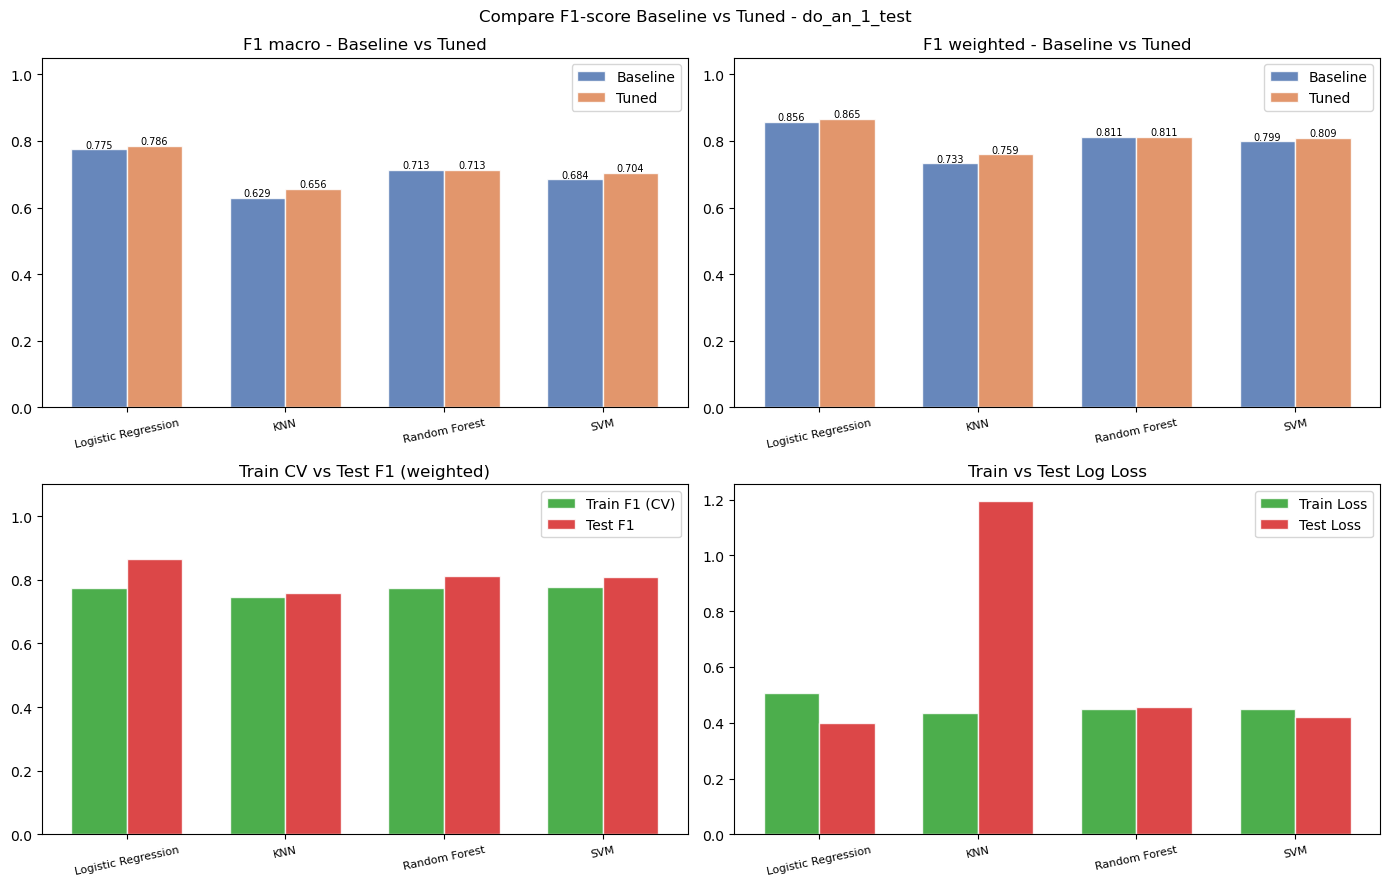

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
models_list = list(cmp_df.index)
x = np.arange(len(models_list)); w = 0.35

ax = axes[0, 0]
ax.bar(x - w/2, cmp_df["F1 macro (base)"],  w, label="Baseline", color="#4C72B0", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, cmp_df["F1 macro (tuned)"], w, label="Tuned",    color="#dd8452", alpha=0.85, edgecolor="white")
for i, (b, t) in enumerate(zip(cmp_df["F1 macro (base)"], cmp_df["F1 macro (tuned)"])):
    ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=7)
    ax.text(i + w/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=12, fontsize=8)
ax.set_ylim(0, 1.05); ax.set_title("F1 macro - Baseline vs Tuned"); ax.legend()

ax = axes[0, 1]
ax.bar(x - w/2, cmp_df["F1 w (base)"],  w, label="Baseline", color="#4C72B0", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, cmp_df["F1 w (tuned)"], w, label="Tuned",    color="#dd8452", alpha=0.85, edgecolor="white")
for i, (b, t) in enumerate(zip(cmp_df["F1 w (base)"], cmp_df["F1 w (tuned)"])):
    ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=7)
    ax.text(i + w/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=12, fontsize=8)
ax.set_ylim(0, 1.05); ax.set_title("F1 weighted - Baseline vs Tuned"); ax.legend()

ax = axes[1, 0]
ax.bar(x - w/2, of_df["Train F1 (CV)"], w, label="Train F1 (CV)", color="#2ca02c", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, of_df["Test F1"],       w, label="Test F1",       color="#d62728", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(of_df.index, rotation=12, fontsize=8)
ax.set_ylim(0, 1.1); ax.set_title("Train CV vs Test F1 (weighted)"); ax.legend()

ax = axes[1, 1]
ax.bar(x - w/2, of_df["Train Loss"], w, label="Train Loss", color="#2ca02c", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, of_df["Test Loss"],  w, label="Test Loss",  color="#d62728", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(of_df.index, rotation=12, fontsize=8)
ax.set_title("Train vs Test Log Loss"); ax.legend()

plt.suptitle(f"Compare F1-score Baseline vs Tuned - {TARGET}", fontsize=12)
plt.tight_layout(); plt.show()

## 10. So sanh & Danh gia ket qua

Chon model tot nhat theo **F1 macro** truoc (can bang ca Pass va Fail), roi **Recall Fail** (de phan thang khi F1 bang nhau).

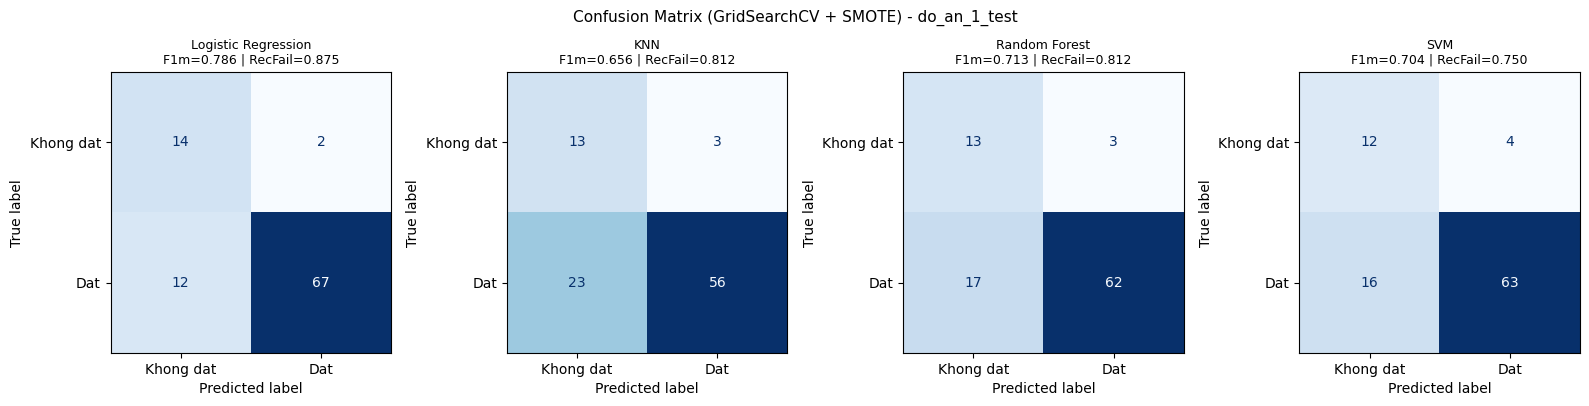

In [66]:
test_rows = []
best_model_info = {"name": None, "recall_fail": -1, "f1_macro": -1}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pipe) in zip(axes, tuned_pipes.items()):
    yp = pipe.predict(Xte); pp = pipe.predict_proba(Xte)

    acc      = accuracy_score(yte, yp)
    p_mac    = precision_score(yte, yp, average="macro",    zero_division=0)
    r_mac    = recall_score(yte, yp,    average="macro",    zero_division=0)
    f_mac    = f1_score(yte, yp,        average="macro",    zero_division=0)
    rec_fail = recall_score(yte, yp, labels=[0], average=None, zero_division=0)[0]
    p_w      = precision_score(yte, yp, average="weighted", zero_division=0)
    r_w      = recall_score(yte, yp,    average="weighted", zero_division=0)
    f_w      = f1_score(yte, yp,        average="weighted", zero_division=0)
    ll       = log_loss(yte, pp)

    test_rows.append({
        "Mo hinh":              name,
        "Accuracy":             round(acc,      4),
        "Precision (macro)":    round(p_mac,    4),
        "Recall (macro)":       round(r_mac,    4),
        "F1 (macro)":           round(f_mac,    4),
        "Recall Fail":          round(rec_fail, 4),
        "Precision (weighted)": round(p_w,      4),
        "Recall (weighted)":    round(r_w,      4),
        "F1 (weighted)":        round(f_w,      4),
        "Log Loss":             round(ll,       4),
    })

    if (f_mac > best_model_info["f1_macro"] or
        (f_mac == best_model_info["f1_macro"] and rec_fail > best_model_info["recall_fail"])):
        best_model_info = {"name": name, "recall_fail": rec_fail, "f1_macro": f_mac}

    cm = confusion_matrix(yte, yp)
    ConfusionMatrixDisplay(cm, display_labels=["Khong dat", "Dat"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nF1m={f_mac:.3f} | RecFail={rec_fail:.3f}", fontsize=9)

plt.suptitle(f"Confusion Matrix (GridSearchCV + SMOTE) - {TARGET}", fontsize=11)
plt.tight_layout(); plt.show()

In [67]:
test_df = pd.DataFrame(test_rows).sort_values(
    ["F1 (macro)", "Recall Fail"], ascending=[False, False])
print("Ket qua tren TEST SET (sap theo F1 macro, roi Recall Fail):")
display(test_df)

print(f"\nBEST MODEL: {best_model_info['name']}")
print(f"   F1 macro    = {best_model_info['f1_macro']:.4f}")
print(f"   Recall Fail = {best_model_info['recall_fail']:.4f}")

best_pipe = tuned_pipes[best_model_info["name"]]
print(f"\nClassification Report - {best_model_info['name']}:")
print(classification_report(yte, best_pipe.predict(Xte),
      target_names=["Khong dat (0)", "Dat (1)"], zero_division=0))

Ket qua tren TEST SET (sap theo F1 macro, roi Recall Fail):


,Mo hinh,Accuracy,Precision (macro),Recall (macro),F1 (macro),Recall Fail,Precision (weighted),Recall (weighted),F1 (weighted),Log Loss
0,Logistic Regression,0.8526,0.7547,0.8616,0.7860,0.8750,0.8982,0.8526,0.8652,0.4006
2,Random Forest,0.7895,0.6936,0.7987,0.7132,0.8125,0.8662,0.7895,0.8113,0.4551
3,SVM,0.7895,0.6844,0.7737,0.7042,0.7500,0.8541,0.7895,0.8095,0.4204
1,KNN,0.7263,0.6551,0.7607,0.6558,0.8125,0.8501,0.7263,0.7591,1.1946



BEST MODEL: Logistic Regression
   F1 macro    = 0.7860
   Recall Fail = 0.8750

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

Khong dat (0)       0.54      0.88      0.67        16
      Dat (1)       0.97      0.85      0.91        79

     accuracy                           0.85        95
    macro avg       0.75      0.86      0.79        95
 weighted avg       0.90      0.85      0.87        95



## 11. Du doan sinh vien nguy co truot - Ca 6 mon

> Model chi fit tren 80% train. Predict toan bo dataset de xac dinh sinh vien can ho tro.
> Pipeline: imp -> smote -> feat(MultiMetricSelector) -> scl -> model.

In [68]:
all_fail, summary_models = [], []

for tgt in TARGET_COLS:
    print(f"\n=== {tgt} ===")
    Xf_, yf_, Xtr_, Xte_, ytr_, yte_, itr_, ite_ = prepare(tgt)
    k_ = min(2, int(ytr_.value_counts().min()) - 1)

    fitted_pipes_, sel_rows_ = {}, []
    for nm_, pipe_ in build_models(k_).items():
        grid_ = GridSearchCV(pipe_, param_grids[nm_], cv=cv5,
                             scoring="f1_macro", n_jobs=-1, verbose=0)
        grid_.fit(Xtr_, ytr_)
        best_est_ = grid_.best_estimator_
        fitted_pipes_[nm_] = best_est_

        yp_   = best_est_.predict(Xte_)
        rec_  = recall_score(yte_, yp_, labels=[0], average=None, zero_division=0)[0]
        f1_   = f1_score(yte_, yp_, average="macro", zero_division=0)
        n_sel = len(best_est_.named_steps["feat"].selected_features_)
        sel_rows_.append({"Model": nm_, "Recall_fail": rec_, "F1_macro": f1_, "N_features": n_sel})
        print(f"  {nm_:22s}: RecFail={rec_:.3f}  F1m={f1_:.3f}  #feat={n_sel}")

    sel_df_ = pd.DataFrame(sel_rows_).sort_values(
        ["F1_macro", "Recall_fail"], ascending=[False, False]).reset_index(drop=True)
    best_nm_ = sel_df_.loc[0, "Model"]
    best_pp_ = fitted_pipes_[best_nm_]

    yp_full   = best_pp_.predict(Xf_)
    fail_mask = (yp_full == 0)
    ids_full  = df.loc[yf_.index, "student_id"].reset_index(drop=True)

    fail_df_ = pd.DataFrame({
        "student_id": ids_full[fail_mask].values,
        "mon_hoc":    tgt,
        "du_doan":    "fail",
        "thuc_te":    yf_.values[fail_mask],
    })
    all_fail.append(fail_df_)
    summary_models.append({
        "Mon":          tgt,
        "Best Model":   best_nm_,
        "Num Features": int(sel_df_.loc[0, "N_features"]),
        "F1 macro":     round(sel_df_.loc[0, "F1_macro"],    4),
        "Recall Fail":  round(sel_df_.loc[0, "Recall_fail"], 4),
        "Du doan Fail": int(fail_mask.sum()),
        "Thuc te Fail": int((yf_ == 0).sum()),
    })

sum_df = pd.DataFrame(summary_models)
print("\n\nBest model tung mon:"); display(sum_df)


=== do_an_1_test ===
  Logistic Regression   : RecFail=0.875  F1m=0.786  #feat=10
  KNN                   : RecFail=0.812  F1m=0.656  #feat=8
  Random Forest         : RecFail=0.812  F1m=0.713  #feat=10
  SVM                   : RecFail=0.750  F1m=0.704  #feat=10

=== kiem_thu_phan_mem_test ===
  Logistic Regression   : RecFail=0.600  F1m=0.598  #feat=8
  KNN                   : RecFail=0.600  F1m=0.598  #feat=8
  Random Forest         : RecFail=0.600  F1m=0.632  #feat=8
  SVM                   : RecFail=0.600  F1m=0.620  #feat=8

=== thiet_ke_web_co_ban_test ===
  Logistic Regression   : RecFail=0.667  F1m=0.638  #feat=8
  KNN                   : RecFail=0.500  F1m=0.534  #feat=8
  Random Forest         : RecFail=0.500  F1m=0.654  #feat=11
  SVM                   : RecFail=0.250  F1m=0.547  #feat=8

=== cong_nghe_phan_mem_test ===
  Logistic Regression   : RecFail=0.625  F1m=0.604  #feat=8
  KNN                   : RecFail=0.750  F1m=0.615  #feat=8
  Random Forest         : RecFail=0

,Mon,Best Model,Num Features,F1 macro,Recall Fail,Du doan Fail,Thuc te Fail
0,do_an_1_test,Logistic Regression,10,0.7860,0.875,144,81
1,kiem_thu_phan_mem_test,Random Forest,8,0.6318,0.600,80,25
2,thiet_ke_web_co_ban_test,Random Forest,11,0.6541,0.500,93,58
3,cong_nghe_phan_mem_test,KNN,8,0.6149,0.750,133,42
4,tieng_anh_1_test,KNN,9,0.7889,0.500,41,32
5,xac_suat_thong_ke_test,Logistic Regression,8,0.7279,0.750,90,39


In [69]:
final_fail  = pd.concat(all_fail, ignore_index=True)
student_sum = (
    final_fail.groupby("student_id")["mon_hoc"].apply(list)
    .reset_index().rename(columns={"mon_hoc":"predicted_fail_subjects"})
)
student_sum["num_fail"] = student_sum["predicted_fail_subjects"].apply(len)
student_sum = student_sum.sort_values(["num_fail","student_id"], ascending=[False,True])
print("Sinh vien nguy co truot nhieu mon nhat:")
display(student_sum.head(30))

Sinh vien nguy co truot nhieu mon nhat:


,student_id,predicted_fail_subjects,num_fail
3,10121101,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
24,10121345,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
30,10121472,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
40,10121640,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
92,10123119,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
105,10123210,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
117,10123281,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
118,10123282,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
123,10123330,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
133,11220025,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6


In [70]:
with pd.ExcelWriter("fail_students_fixed_n6.xlsx") as writer:
    final_fail.to_excel(writer, sheet_name="fail_by_subject", index=False)
    student_sum.to_excel(writer, sheet_name="fail_by_student", index=False)
    sum_df.to_excel(writer, sheet_name="best_models", index=False)
print("Da xuat: fail_students_fixed_n6.xlsx")

Da xuat: fail_students_fixed_n6.xlsx
